# Controlled probabilistic ordering with event templates

Consider a task where most trials show a single, plain stimulus, but occasionally a trial triggers a short burst of related events. For example, a typical trial is a sequence `cue -> outcome`, while rare "surprise" trials play out as `cue -> outcome -> feedback`. In the case you need to randomize the presentation order of these two trial types, you need to be able to define the trial types and to assign each trial type probabilities of occurence.

That is what template-based ordering is for. In this tutorial, we will define a small set of reusable trial "templates", and `neurodesign-plus` will sample a sequence of templates according to probabilities you choose.

By the end of this tutorial, you will know how to:

1. define `trial_templates`, `trial_template_probabilities`, and `n_conceptual_trials`,
2. understand how probabilistic template sampling differs from ordinary random ordering,
3. inspect whether the sampled conceptual trials respect the intended motif structure.


In [5]:
import os
import random
from collections import Counter

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import neurodesign

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 110


## 1. Sample from event templates instead of single events

With template-based ordering, you predefine a small set of **conceptual trial templates**. Each template is a defined as a fixed sequence of one or more events, with a predefined durations. `neurodesign-plus` then samples a sequence of templates, one per trial, and lays out their events one after another to build the final event-level order.

Three parameters control this:

- `trial_templates` is the list of templates to choose from. Each template needs a `template_id` (a name you pick), a `trial_type`, and an `events` list describing what happens inside that trial — one entry per event, each with a `category`, a `code`, and a `duration`.
- `trial_template_probabilities` gives the probability of drawing each template, in the same order as `trial_templates`. These must be non-negative and sum to 1.
- `n_conceptual_trials` sets how many trials — i.e. how many templates — get sampled in total.

Because templates are always sampled intact, the *number of trials* is fixed by `n_conceptual_trials`, but the *number of events* is not — it depends on which templates happen to be drawn. A run made mostly of single-event templates ends up with fewer total events than a run made mostly of multi-event templates, even with the same `n_conceptual_trials`. You'll see this directly in the example below: the same `n_conceptual_trials = 10` produces a different total event count each time you resample.


In [6]:
random.seed(2026)

trial_templates = [
    {
        "template_id": "single",
        "trial_type": "single",
        "events": [{"category": "event0", "code": 0, "duration": 1}],
    },
    {
        "template_id": "motif",
        "trial_type": "motif",
        "events": [
            {"category": "event1", "code": 1, "duration": 1},
            {"category": "event2", "code": 2, "duration": 1},
            {"category": "event3", "code": 3, "duration": 1},
        ],
    },
]
trial_template_probabilities = [0.5, 0.5]
n_conceptual_trials = 10


def sample_conceptual_trials(templates, probabilities, n_trials):
    sampled_templates = random.choices(templates, weights=probabilities, k=n_trials)
    flattened = [
        event["code"]
        for template in sampled_templates
        for event in template["events"]
    ]
    return sampled_templates, flattened


preview_templates, preview_order = sample_conceptual_trials(
    trial_templates,
    trial_template_probabilities,
    n_conceptual_trials,
)

print("Preview sampled conceptual trials:", [t["template_id"] for t in preview_templates])
print("Preview flattened order:", preview_order)
print("Condition counts:", dict(Counter(preview_order)))


Preview sampled conceptual trials: ['single', 'motif', 'motif', 'motif', 'single', 'single', 'motif', 'motif', 'motif', 'motif']
Preview flattened order: [0, 1, 2, 3, 1, 2, 3, 1, 2, 3, 0, 0, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3]
Condition counts: {0: 3, 1: 7, 2: 7, 3: 7}


In this example, event `0` may appear on its own, while event `1` is intended to bring along the motif `1 -> 2 -> 3`. In case of doubt, a preview of the sampled conceptual trials is useful to see the templates and the resulting event-level order before any optimization is involved.

We now pass the same `trial_templates` to an `Experiment` so that every candidate design is generated from the same motif logic.


In [7]:
def internal_triplet_violations(order):
    violations = []
    for idx in range(len(order) - 2):
        if order[idx] == 1 and order[idx : idx + 3] != [1, 2, 3]:
            violations.append((idx, order[idx : idx + 3]))
    return violations


random.seed(2026)
exp = neurodesign.Experiment(
    TR=2,
    P=[0.25, 0.25, 0.25, 0.25],
    C=[[1, 0, -1, 0], [1, 0, 0, -1], [0, 1, -1, 0], [0, 1, 0, -1]],
    n_stimuli=4,
    rho=0.3,
    trial_start_interval=0.5,
    post_event_interval=2,
    inter_trial_interval={"model": "uniform", "min": 1, "max": 4, "mean": 2.5},
    trial_templates=trial_templates,
    trial_template_probabilities=trial_template_probabilities,
    n_conceptual_trials=n_conceptual_trials,
)

population = neurodesign.Optimisation(
    experiment=exp,
    R=[1, 0, 0],
    weights=[0, 0.5, 0.25, 0.25],  # order: Fe, Fd, Ff, Fc
    preruncycles=1,
    cycles=2,
    outdes=1,
    I=1,
    G=2,
    folder="./",
    seed=100,
)

population.optimise()

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\.venv\Lib\site-packages\rich\live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:1031: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(


Best sampled conceptual trials: ['motif', 'motif', 'single', 'motif', 'single', 'single', 'motif', 'motif', 'motif', 'single']
Best flattened order: [1, 2, 3, 1, 2, 3, 0, 1, 2, 3, 0, 0, 1, 2, 3, 1, 2, 3, 1, 2, 3, 0]
Internal 1-2-3 motif violations: []
Number of conceptual trials: 10
Number of flattened events: 22
Condition counts: {1: 6, 2: 6, 3: 6, 0: 4}
Fd (detection efficiency): 1.0534
Fe (estimation efficiency): 0.0000
Fc (confounding score): 0.4361
Ff (frequency-balance score): 0.9091


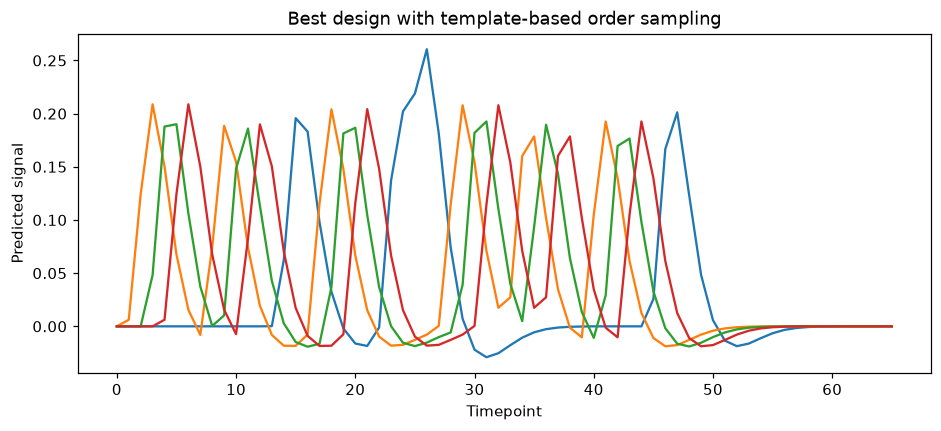

In [8]:
best_design = population.selected_design(0)
best_design.designmatrix()

best_order = list(best_design.order)
best_templates = list(best_design.trial_template_ids)
violations = internal_triplet_violations(best_order)

print("Best sampled conceptual trials:", best_templates)
print("Best flattened order:", best_order)
print("Internal 1-2-3 motif violations:", violations)
print("Number of conceptual trials:", len(best_templates))
print("Number of flattened events:", len(best_order))
print("Condition counts:", dict(Counter(best_order)))
print(f"Fd (detection efficiency): {best_design.Fd:.4f}")
print(f"Fe (estimation efficiency): {best_design.Fe:.4f}")
print(f"Fc (confounding score): {best_design.Fc:.4f}")
print(f"Ff (frequency-balance score): {best_design.Ff:.4f}")

fig, ax = plt.subplots()
ax.plot(best_design.Xconv)
ax.set_title("Best design with template-based order sampling")
ax.set_xlabel("Timepoint")
ax.set_ylabel("Predicted signal")
plt.show()


## 2. How to read the result

- the flattened order should show the intended motif structure throughout,
- the number of conceptual trials should equal `n_conceptual_trials`, while the number of flattened events varies with which templates were sampled.

This feature is intended for biasing sampling toward recurring local sequences.


## 3. Takeaway

Use template-based ordering when the design should be sampled from event motifs rather than from fully independent event codes. To perform template-based ordering:

- put the motifs in `trial_templates`, each with a `template_id`, `trial_type`, and `events` list,
- match their sampling weights in `trial_template_probabilities`,
- set `n_conceptual_trials` to the desired number of conceptual trials,
- remember that the flattened event-level order is not truncated or padded, so its length varies with the sampled templates.
